In [35]:
import pandas as pd

df = pd.read_csv('hasil_eval_model_final_v2_fixed.csv')
df



,instruction,input,true_output,true_label,true_reasoning,pred_output,pred_label,pred_reasoning,pred_formatted,is_correct,...,global_bertscore_recall,global_bertscore_f1,global_train_loss,global_train_ppl,global_eval_loss,global_eval_ppl,total_test_samples,total_correct,unknown_pred,unknown_true
0,<s>[SYSTEM_PROMPT]Anda adalah sistem deteksi k...,Klaim: 'Judul: Potret 'Asal Untung' di Kalanga...,Label: **Ujaran Kebencian.** penjelasan: Teks ...,ujaran_kebencian,Teks menggeneralisir orang Minangkabau dengan ...,Label: **Ujaran Kebencian.** penjelasan: Claim...,ujaran_kebencian,Claim ini memberikan label negatif dan atribut...,[LABEL] UJARAN_KEBENCIAN [REASONING] Claim ini...,True,...,0.824948,0.823531,NaN,NaN,NaN,NaN,2599,2589,0,0
1,<s>[SYSTEM_PROMPT]Anda adalah sistem deteksi k...,"Klaim: 'wkwk kreatif banget loh ini madingnya,...",Label: **Bukan DFK.** penjelasan: Komentar ini...,non_dfk,Komentar ini hanya mengekspresikan apresiasi t...,Label: **Bukan DFK.** penjelasan: Komentar ini...,non_dfk,"Komentar ini bersifat ekspresif dan basa-basi,...",[LABEL] NON_DFK [REASONING] Komentar ini bersi...,True,...,0.824948,0.823531,NaN,NaN,NaN,NaN,2599,2589,0,0
2,<s>[SYSTEM_PROMPT]Anda adalah sistem deteksi k...,Klaim: 'Heboh! Kantor PKS Digeruduk dan Dibaka...,Label: **Disinformasi.** penjelasan: Klaim ini...,disinformasi,Klaim ini adalah konten menyesatkan yang meman...,Label: **Disinformasi.** penjelasan: Ini adala...,disinformasi,Ini adalah modus konten menyesatkan yang mengg...,[LABEL] DISINFORMASI [REASONING] Ini adalah mo...,True,...,0.824948,0.823531,NaN,NaN,NaN,NaN,2599,2589,0,0
3,<s>[SYSTEM_PROMPT]Anda adalah sistem deteksi k...,Klaim: 'Judul: Kritik Terhadap Budaya Hemat ya...,Label: **Ujaran Kebencian.** penjelasan: Claim...,ujaran_kebencian,Claim menggeneralisir masyarakat Minangkabau s...,Label: **Ujaran Kebencian.** penjelasan: Claim...,ujaran_kebencian,Claim ini memberikan label negatif dan atribut...,[LABEL] UJARAN_KEBENCIAN [REASONING] Claim ini...,True,...,0.824948,0.823531,NaN,NaN,NaN,NaN,2599,2589,0,0
4,<s>[SYSTEM_PROMPT]Anda adalah sistem deteksi k...,Klaim: 'Buruan ikutan giveaway PLN! Dapatkan u...,Label: **Disinformasi.** penjelasan: Ini adala...,disinformasi,Ini adalah modus phishing yang mencatut nama P...,Label: **Disinformasi.** penjelasan: Ini adala...,disinformasi,Ini adalah modus phishing yang mencatut nama P...,[LABEL] DISINFORMASI [REASONING] Ini adalah mo...,True,...,0.824948,0.823531,NaN,NaN,NaN,NaN,2599,2589,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2594,<s>[SYSTEM_PROMPT]Anda adalah sistem deteksi k...,Klaim: 'Pemkab Jembrana menerapkan sentralisas...,Label: **Fakta.** penjelasan: Informasi ini se...,fakta,Informasi ini selaras dengan fakta asli dari b...,Label: **Fakta.** penjelasan: Informasi ini se...,fakta,Informasi ini sesuai dengan narasi berita yang...,[LABEL] FAKTA [REASONING] Informasi ini sesuai...,True,...,0.824948,0.823531,NaN,NaN,NaN,NaN,2599,2589,0,0
2595,<s>[SYSTEM_PROMPT]Anda adalah sistem deteksi k...,Klaim: 'Operasi Modifikasi Cuaca di Jambi hany...,Label: **Fitnah.** penjelasan: Claim tersebut ...,fitnah,Claim tersebut menggunakan framing negatif den...,Label: **Fitnah.** penjelasan: Claim tersebut ...,fitnah,Claim tersebut menggunakan framing negatif dan...,[LABEL] FITNAH [REASONING] Claim tersebut meng...,True,...,0.824948,0.823531,NaN,NaN,NaN,NaN,2599,2589,0,0
2596,<s>[SYSTEM_PROMPT]Anda adalah sistem deteksi k...,Klaim: 'Judul: Mengapa Jabatan Strategis Selal...,Label: **Ujaran Kebencian.** penjelasan: Naras...,ujaran_kebencian,Narasi ini memberikan label negatif dan atribu...,Label: **Ujaran Kebencian.** penjelasan: Claim...,ujaran_kebencian,Claim ini memberikan label negatif dan atribut...,[LABEL] UJARAN_KEBENCIAN [REASONING] Claim ini...,True,...,0.824948,0.823531,NaN,NaN,NaN,NaN,2599,2589,0,0
2597,<s>[SYSTEM_PROMPT]Anda adalah sistem deteksi k...,Klaim: 'Diskominfo Sukabumi imbau waspada peni...,Label: **Fakta.** penjelasan: 

## unknown

In [36]:
count_unknown = df["pred_label"].astype(str).str.strip().str.lower().eq("unknown").sum()
print(count_unknown)


0


In [37]:
unknown_rows = df[
    df["pred_label"]
      .astype(str)
      .str.strip()
      .str.lower()
      .isin(["unknown", "unknow"])
]

print("Total rows with pred_label unknown:", len(unknown_rows))
unknown_rows

Total rows with pred_label unknown: 0


,instruction,input,true_output,true_label,true_reasoning,pred_output,pred_label,pred_reasoning,pred_formatted,is_correct,...,global_bertscore_recall,global_bertscore_f1,global_train_loss,global_train_ppl,global_eval_loss,global_eval_ppl,total_test_samples,total_correct,unknown_pred,unknown_true


## salah parsing label

In [38]:
mask = df["true_output"].astype(str).str.contains("Bukan DFK.", case=False, regex=False, na=False)
df_bukan_dfk = df[mask]
print("Total rows with true_output containing Bukan DFK.:", len(df_bukan_dfk))
df_bukan_dfk

Total rows with true_output containing Bukan DFK.: 512


,instruction,input,true_output,true_label,true_reasoning,pred_output,pred_label,pred_reasoning,pred_formatted,is_correct,...,global_bertscore_recall,global_bertscore_f1,global_train_loss,global_train_ppl,global_eval_loss,global_eval_ppl,total_test_samples,total_correct,unknown_pred,unknown_true
1,<s>[SYSTEM_PROMPT]Anda adalah sistem deteksi k...,"Klaim: 'wkwk kreatif banget loh ini madingnya,...",Label: **Bukan DFK.** penjelasan: Komentar ini...,non_dfk,Komentar ini hanya mengekspresikan apresiasi t...,Label: **Bukan DFK.** penjelasan: Komentar ini...,non_dfk,"Komentar ini bersifat ekspresif dan basa-basi,...",[LABEL] NON_DFK [REASONING] Komentar ini bersi...,True,...,0.824948,0.823531,NaN,NaN,NaN,NaN,2599,2589,0,0
9,<s>[SYSTEM_PROMPT]Anda adalah sistem deteksi k...,Klaim: 'anjngMarc sama Fabio udah ngaspal di M...,Label: **Bukan DFK.** penjelasan: Komentar ini...,non_dfk,Komentar ini hanya mengekspresikan reaksi neti...,Label: **Bukan DFK.** penjelasan: Komentar ini...,non_dfk,"Komentar ini bersifat ekspresif dan basa-basi,...",[LABEL] NON_DFK [REASONING] Komentar ini bersi...,True,...,0.824948,0.823531,NaN,NaN,NaN,NaN,2599,2589,0,0
13,<s>[SYSTEM_PROMPT]Anda adalah sistem deteksi k...,"Klaim: 'ngebayangin aja udah ngiler, harus cob...",Label: **Bukan DFK.** penjelasan: Komentar ini...,non_dfk,Komentar ini hanya mengungkapkan reaksi positi...,Label: **Bukan DFK.** penjelasan: Komentar ini...,non_dfk,"Komentar ini bersifat ekspresif dan basa-basi,...",[LABEL] NON_DFK [REASONING] Komentar ini bersi...,True,...,0.824948,0.823531,NaN,NaN,NaN,NaN,2599,2589,0,0
14,<s>[SYSTEM_PROMPT]Anda adalah sistem deteksi k...,Klaim: 'eh akhirnya lanjut juga nih liga. semo...,Label: **Bukan DFK.** penjelasan: Komentar ini...,non_dfk,"Komentar ini bersifat ekspresif dan mendukung,...",Label: **Bukan DFK.** penjelasan: Komentar ini...,non_dfk,Komentar ini bersifat ekspresif dan hanya meng...,[LABEL] NON_DFK [REASONING] Komentar ini bersi...,True,...,0.824948,0.823531,NaN,NaN,NaN,NaN,2599,2589,0,0
20,<s>[SYSTEM_PROMPT]Anda adalah sistem deteksi k...,"Klaim: 'iya betul deh, jangan dicari sensasiny...",Label: **Bukan DFK.** penjelasan: Komentar ini...,non_dfk,Komentar ini bersifat ekspresif dan mendukung ...,Label: **Bukan DFK.** penjelasan: Komentar ini...,non_dfk,Komentar ini bersifat ekspresif dan mendukung ...,[LABEL] NON_DFK [REASONING] Komentar ini bersi...,True,...,0.824948,0.823531,NaN,NaN,NaN,NaN,2599,2589,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2583,<s>[SYSTEM_PROMPT]Anda adalah sistem deteksi k...,"Klaim: 'anjirr, Gustavo Fernandes tingginya 1,...",Label: **Bukan DFK.** penjelasan: Komentar ini...,non_dfk,Komentar ini bersifat ekspresif dan berisi rea...,Label: **Bukan DFK.** penjelasan: Komentar ini...,non_dfk,"Komentar ini bersifat ekspresif dan basa-basi,...",[LABEL] NON_DFK [REASONING] Komentar ini bersi...,True,...,0.824948,0.823531,NaN,NaN,NaN,NaN,2599,2589,0,0
2584,<s>[SYSTEM_PROMPT]Anda adalah sistem deteksi k...,"Klaim: 'bro, ini ambang batas fraksi itu apa s...",Label: **Bukan DFK.** penjelasan: Komentar ini...,non_dfk,Komentar ini bersifat basa-basi dan mencermink...,Label: **Bukan DFK.** penjelasan: Komentar ini...,non_dfk,Komentar ini bersifat ekspresif dan hanya meng...,[LABEL] NON_DFK [REASONING] Komentar ini bersi...,True,...,0.824948,0.823531,NaN,NaN,NaN,NaN,2599,2589,0,0
2585,<s>[SYSTEM_PROMPT]Anda adalah sistem deteksi k...,"Klaim: 'bjir, bisa dapet mobil gitu, enak bang...",Label: **Bukan DFK.** penjelasan: Komentar ini...,non_dfk,Komentar ini bersifat ekspresif dan memberikan...,Label: **Bukan DFK.** penjelasan: Komentar ini...,non_dfk,"Komentar ini bersifat ekspresif dan basa-basi,...",[LABEL] NON_DFK [REASONING] Komentar ini bersi...,True,...,0.824948,0.823531,NaN,NaN,NaN,NaN,2599,2589,0,0
2592,<s>[SYSTEM_PROMPT]Anda adalah sistem deteksi k...,"Klaim: 'eh iya nih, biaya haji naik lagi. ngga...",Label: **Bukan DFK.** penjelasan: Komentar ini...,non_dfk,Komentar ini be

In [15]:
mask = df["true_output"].astype(str).str.contains("Bukan DFK.", case=False, regex=False, na=False)
df_bukan_dfk = df[mask].copy()
df_bukan_dfk["true_label"] = "non_dfk"

df.loc[df_bukan_dfk.index, "true_label"] = df_bukan_dfk["true_label"]

print("Total rows with true_output containing Bukan DFK.:", len(df_bukan_dfk))
df_bukan_dfk

Total rows with true_output containing Bukan DFK.: 512


,instruction,input,true_output,true_label,true_reasoning,pred_output,pred_label,pred_reasoning,pred_formatted,is_correct,...,global_bertscore_recall,global_bertscore_f1,global_train_loss,global_train_ppl,global_eval_loss,global_eval_ppl,total_test_samples,total_correct,unknown_pred,unknown_true
1,<s>[SYSTEM_PROMPT]Anda adalah sistem deteksi k...,"Klaim: 'wkwk kreatif banget loh ini madingnya,...",Label: **Bukan DFK.** penjelasan: Komentar ini...,non_dfk,Komentar ini hanya mengekspresikan apresiasi t...,"Label: **Fakta.**\n\nPenjelasan:\n- Klaim: ""wk...",fakta,"- Klaim: ""wkwk kreatif banget loh ini madingny...","[LABEL] FAKTA [REASONING] - Klaim: ""wkwk kreat...",False,...,0.684227,0.709777,NaN,NaN,NaN,NaN,2599,1072,229,285
9,<s>[SYSTEM_PROMPT]Anda adalah sistem deteksi k...,Klaim: 'anjngMarc sama Fabio udah ngaspal di M...,Label: **Bukan DFK.** penjelasan: Komentar ini...,non_dfk,Komentar ini hanya mengekspresikan reaksi neti...,Label: Fakta.\n\npenjelasan: Klaim tersebut se...,fakta,Klaim tersebut sesuai dengan informasi yang te...,[LABEL] FAKTA [REASONING] Klaim tersebut sesua...,True,...,0.684227,0.709777,NaN,NaN,NaN,NaN,2599,1072,229,285
13,<s>[SYSTEM_PROMPT]Anda adalah sistem deteksi k...,"Klaim: 'ngebayangin aja udah ngiler, harus cob...",Label: **Bukan DFK.** penjelasan: Komentar ini...,non_dfk,Komentar ini hanya mengungkapkan reaksi positi...,Label: **Fakta.**\n\npenjelasan: Klaim tersebu...,fakta,Klaim tersebut sejalan dengan artikel rujukan....,[LABEL] FAKTA [REASONING] Klaim tersebut sejal...,False,...,0.684227,0.709777,NaN,NaN,NaN,NaN,2599,1072,229,285
14,<s>[SYSTEM_PROMPT]Anda adalah sistem deteksi k...,Klaim: 'eh akhirnya lanjut juga nih liga. semo...,Label: **Bukan DFK.** penjelasan: Komentar ini...,non_dfk,"Komentar ini bersifat ekspresif dan mendukung,...",Label: Fakta.\n\npenjelasan: Klaim tersebut me...,fakta,Klaim tersebut merupakan fakta yang benar berd...,[LABEL] FAKTA [REASONING] Klaim tersebut merup...,False,...,0.684227,0.709777,NaN,NaN,NaN,NaN,2599,1072,229,285
20,<s>[SYSTEM_PROMPT]Anda adalah sistem deteksi k...,"Klaim: 'iya betul deh, jangan dicari sensasiny...",Label: **Bukan DFK.** penjelasan: Komentar ini...,non_dfk,Komentar ini bersifat ekspresif dan mendukung ...,Label: Fakta.\n\npenjelasan: Klaim tersebut se...,fakta,Klaim tersebut sesuai dengan informasi yang di...,[LABEL] FAKTA [REASONING] Klaim tersebut sesua...,False,...,0.684227,0.709777,NaN,NaN,NaN,NaN,2599,1072,229,285
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2583,<s>[SYSTEM_PROMPT]Anda adalah sistem deteksi k...,"Klaim: 'anjirr, Gustavo Fernandes tingginya 1,...",Label: **Bukan DFK.** penjelasan: Komentar ini...,non_dfk,Komentar ini bersifat ekspresif dan berisi rea...,Label: Fakta.\n\npenjelasan: Klaim tersebut me...,fakta,Klaim tersebut mengandung fakta yang dapat div...,[LABEL] FAKTA [REASONING] Klaim tersebut menga...,True,...,0.684227,0.709777,NaN,NaN,NaN,NaN,2599,1072,229,285
2584,<s>[SYSTEM_PROMPT]Anda adalah sistem deteksi k...,"Klaim: 'bro, ini ambang batas fraksi itu apa s...",Label: **Bukan DFK.** penjelasan: Komentar ini...,non_dfk,Komentar ini bersifat basa-basi dan mencermink...,Label: Fakta\n\npenjelasan: Artikel rujukan me...,fakta,Artikel rujukan memberikan informasi tentang r...,[LABEL] FAKTA [REASONING] Artikel rujukan memb...,False,...,0.684227,0.709777,NaN,NaN,NaN,NaN,2599,1072,229,285
2585,<s>[SYSTEM_PROMPT]Anda adalah sistem deteksi k...,"Klaim: 'bjir, bisa dapet mobil gitu, enak bang...",Label: **Bukan DFK.** penjelasan: Komentar ini...,non_dfk,Komentar ini bersifat ekspresif dan memberikan...,Label: Fakta.\n\npenjelasan: Klaim tersebut me...,fakta,Klaim tersebut merupakan fakta yang benar. Hal...,[LABEL] FAKTA [REASONING] Klaim tersebut merup...,True,...,0.684227,0.709777,NaN,NaN,NaN,NaN,2599,1072,229,285
2592,<s>[SYSTEM_PROMPT]Anda adalah sistem deteksi k...,"Klaim: 'eh iya nih, biaya haji naik lagi. ngga...",Label: **Bukan DFK.** penjelasan: Komentar ini...,non

In [11]:
mask = df["true_output"].astype(str).str.contains("Bukan DFK.", case=False, regex=False, na=False)

wrong_rows = df[mask & (df["true_label"] != "non_dfk")]
extra_rows = df[(~mask) & (df["true_label"] == "non_dfk")]

print("Total rows with true_output containing Bukan DFK.:", mask.sum())
print("Rows where true_output contains Bukan DFK. but true_label is not non_dfk:", len(wrong_rows))
print("Rows where true_label is non_dfk but true_output does not contain Bukan DFK.:", len(extra_rows))

wrong_rows, extra_rows

Total rows with true_output containing Bukan DFK.: 512
Rows where true_output contains Bukan DFK. but true_label is not non_dfk: 0
Rows where true_label is non_dfk but true_output does not contain Bukan DFK.: 0


(Empty DataFrame
 Columns: [instruction, input, true_output, true_label, true_reasoning, pred_output, pred_label, pred_reasoning, pred_formatted, is_correct, confidence_mtla, rouge_l_per_row, bertscore_precision_per_row, bertscore_recall_per_row, bertscore_f1_per_row, per_sample_loss, per_sample_ppl, global_accuracy, global_precision, global_recall, global_macro_f1, global_mcc, global_rouge_l, global_bertscore_precision, global_bertscore_recall, global_bertscore_f1, global_train_loss, global_train_ppl, global_eval_loss, global_eval_ppl, total_test_samples, total_correct, unknown_pred, unknown_true]
 Index: []
 
 [0 rows x 34 columns],
 Empty DataFrame
 Columns: [instruction, input, true_output, true_label, true_reasoning, pred_output, pred_label, pred_reasoning, pred_formatted, is_correct, confidence_mtla, rouge_l_per_row, bertscore_precision_per_row, bertscore_recall_per_row, bertscore_f1_per_row, per_sample_loss, per_sample_ppl, global_accuracy, global_precision, global_recall, globa

In [23]:
count_true_unknown = df["true_label"].astype(str).str.strip().str.lower().eq("unknown").sum()
count_pred_unknown = df["pred_label"].astype(str).str.strip().str.lower().eq("unknown").sum()

df["unknown_true"] = 0

print("unknown in true_label:", count_true_unknown)
print("unknown in pred_label:", count_pred_unknown)
print("All values in unknown_true are now set to 0.")

unknown in true_label: 0
unknown in pred_label: 229
All values in unknown_true are now set to 0.


In [25]:
df.to_csv('hasil_eval_model_base_v2_fixed2.csv', index=False)

# evaluasi metrik

In [47]:
import pandas as pd

df = pd.read_csv('hasil_eval_model_final_v2_fixed.csv')
df



,instruction,input,true_output,true_label,true_reasoning,pred_output,pred_label,pred_reasoning,pred_formatted,is_correct,...,global_bertscore_recall,global_bertscore_f1,global_train_loss,global_train_ppl,global_eval_loss,global_eval_ppl,total_test_samples,total_correct,unknown_pred,unknown_true
0,<s>[SYSTEM_PROMPT]Anda adalah sistem deteksi k...,Klaim: 'Judul: Potret 'Asal Untung' di Kalanga...,Label: **Ujaran Kebencian.** penjelasan: Teks ...,ujaran_kebencian,Teks menggeneralisir orang Minangkabau dengan ...,Label: **Ujaran Kebencian.** penjelasan: Claim...,ujaran_kebencian,Claim ini memberikan label negatif dan atribut...,[LABEL] UJARAN_KEBENCIAN [REASONING] Claim ini...,True,...,0.824948,0.823531,NaN,NaN,NaN,NaN,2599,2589,0,0
1,<s>[SYSTEM_PROMPT]Anda adalah sistem deteksi k...,"Klaim: 'wkwk kreatif banget loh ini madingnya,...",Label: **Bukan DFK.** penjelasan: Komentar ini...,non_dfk,Komentar ini hanya mengekspresikan apresiasi t...,Label: **Bukan DFK.** penjelasan: Komentar ini...,non_dfk,"Komentar ini bersifat ekspresif dan basa-basi,...",[LABEL] NON_DFK [REASONING] Komentar ini bersi...,True,...,0.824948,0.823531,NaN,NaN,NaN,NaN,2599,2589,0,0
2,<s>[SYSTEM_PROMPT]Anda adalah sistem deteksi k...,Klaim: 'Heboh! Kantor PKS Digeruduk dan Dibaka...,Label: **Disinformasi.** penjelasan: Klaim ini...,disinformasi,Klaim ini adalah konten menyesatkan yang meman...,Label: **Disinformasi.** penjelasan: Ini adala...,disinformasi,Ini adalah modus konten menyesatkan yang mengg...,[LABEL] DISINFORMASI [REASONING] Ini adalah mo...,True,...,0.824948,0.823531,NaN,NaN,NaN,NaN,2599,2589,0,0
3,<s>[SYSTEM_PROMPT]Anda adalah sistem deteksi k...,Klaim: 'Judul: Kritik Terhadap Budaya Hemat ya...,Label: **Ujaran Kebencian.** penjelasan: Claim...,ujaran_kebencian,Claim menggeneralisir masyarakat Minangkabau s...,Label: **Ujaran Kebencian.** penjelasan: Claim...,ujaran_kebencian,Claim ini memberikan label negatif dan atribut...,[LABEL] UJARAN_KEBENCIAN [REASONING] Claim ini...,True,...,0.824948,0.823531,NaN,NaN,NaN,NaN,2599,2589,0,0
4,<s>[SYSTEM_PROMPT]Anda adalah sistem deteksi k...,Klaim: 'Buruan ikutan giveaway PLN! Dapatkan u...,Label: **Disinformasi.** penjelasan: Ini adala...,disinformasi,Ini adalah modus phishing yang mencatut nama P...,Label: **Disinformasi.** penjelasan: Ini adala...,disinformasi,Ini adalah modus phishing yang mencatut nama P...,[LABEL] DISINFORMASI [REASONING] Ini adalah mo...,True,...,0.824948,0.823531,NaN,NaN,NaN,NaN,2599,2589,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2594,<s>[SYSTEM_PROMPT]Anda adalah sistem deteksi k...,Klaim: 'Pemkab Jembrana menerapkan sentralisas...,Label: **Fakta.** penjelasan: Informasi ini se...,fakta,Informasi ini selaras dengan fakta asli dari b...,Label: **Fakta.** penjelasan: Informasi ini se...,fakta,Informasi ini sesuai dengan narasi berita yang...,[LABEL] FAKTA [REASONING] Informasi ini sesuai...,True,...,0.824948,0.823531,NaN,NaN,NaN,NaN,2599,2589,0,0
2595,<s>[SYSTEM_PROMPT]Anda adalah sistem deteksi k...,Klaim: 'Operasi Modifikasi Cuaca di Jambi hany...,Label: **Fitnah.** penjelasan: Claim tersebut ...,fitnah,Claim tersebut menggunakan framing negatif den...,Label: **Fitnah.** penjelasan: Claim tersebut ...,fitnah,Claim tersebut menggunakan framing negatif dan...,[LABEL] FITNAH [REASONING] Claim tersebut meng...,True,...,0.824948,0.823531,NaN,NaN,NaN,NaN,2599,2589,0,0
2596,<s>[SYSTEM_PROMPT]Anda adalah sistem deteksi k...,Klaim: 'Judul: Mengapa Jabatan Strategis Selal...,Label: **Ujaran Kebencian.** penjelasan: Naras...,ujaran_kebencian,Narasi ini memberikan label negatif dan atribu...,Label: **Ujaran Kebencian.** penjelasan: Claim...,ujaran_kebencian,Claim ini memberikan label negatif dan atribut...,[LABEL] UJARAN_KEBENCIAN [REASONING] Claim ini...,True,...,0.824948,0.823531,NaN,NaN,NaN,NaN,2599,2589,0,0
2597,<s>[SYSTEM_PROMPT]Anda adalah sistem deteksi k...,Klaim: 'Diskominfo Sukabumi imbau waspada peni...,Label: **Fakta.** penjelasan: 

Accuracy: 0.9961523662947287
Macro Precision: 0.9961742604961831
Macro Recall: 0.9961284503980725
Macro F1: 0.9961321355861854
Confusion matrix labels: ['disinformasi', 'fakta', 'fitnah', 'non_dfk', 'ujaran_kebencian']


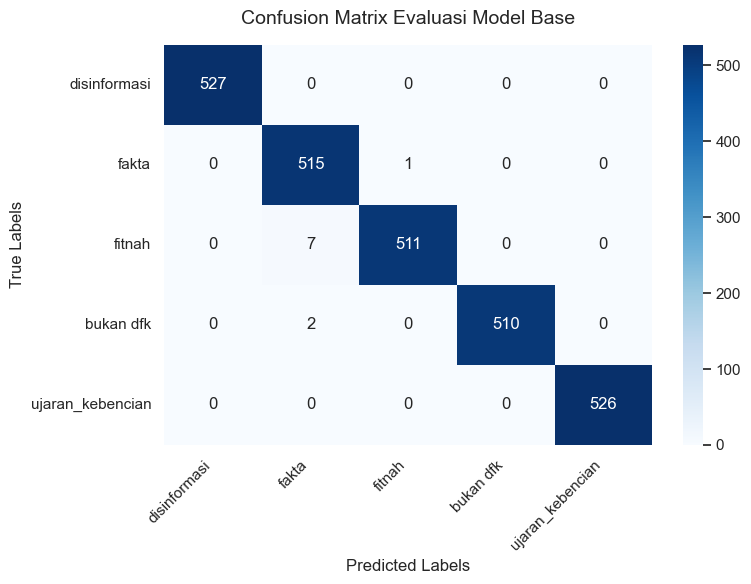

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)

# Standardize labels for comparison
y_true = df["true_label"].astype(str).str.strip().str.lower()
y_pred = df["pred_label"].astype(str).str.strip().str.lower()

# Mendapatkan urutan label unik asli dari data
labels = sorted(set(y_true) | set(y_pred))

# Kalkulasi Metrik (tetap menggunakan label asli agar perhitungan presisi)
accuracy = accuracy_score(y_true, y_pred)
macro_precision = precision_score(y_true, y_pred, average="macro", zero_division=0)
macro_recall = recall_score(y_true, y_pred, average="macro", zero_division=0)
macro_f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)
cm = confusion_matrix(y_true, y_pred, labels=labels)

print("Accuracy:", accuracy)
print("Macro Precision:", macro_precision)
print("Macro Recall:", macro_recall)
print("Macro F1:", macro_f1)
print("Confusion matrix labels:", labels)

# === MAPPING LABEL KHUSUS UNTUK TAMPILAN GAMBAR ===
# Mengubah 'non_dfk' menjadi 'bukan dfk' khusus untuk display tick gambar
display_labels = [
    "bukan dfk" if label == "non_dfk" else label for label in labels
]

# === MAPPING LABEL KHUSUS UNTUK TAMPILAN GAMBAR ===
display_labels = [
    "bukan dfk"
    if label == "non_dfk"
    else "unparseable"
    if label == "unknown"
    else label
    for label in labels
]

# === BAGIAN VISUALISASI CONFUSION MATRIX ===
plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=display_labels,  # Menggunakan label baru yang sudah di-map
    yticklabels=display_labels,  # Menggunakan label baru yang sudah di-map
    cbar=True,
)

plt.title("Confusion Matrix Evaluasi Model Base", fontsize=14, pad=15)
plt.xlabel("Predicted Labels", fontsize=12)
plt.ylabel("True Labels", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()

plt.show()

In [43]:
import pandas as pd

df = pd.read_csv('hasil_eval_model_base_v2_fixed2.csv')
df



,instruction,input,true_output,true_label,true_reasoning,pred_output,pred_label,pred_reasoning,pred_formatted,is_correct,...,global_bertscore_recall,global_bertscore_f1,global_train_loss,global_train_ppl,global_eval_loss,global_eval_ppl,total_test_samples,total_correct,unknown_pred,unknown_true
0,<s>[SYSTEM_PROMPT]Anda adalah sistem deteksi k...,Klaim: 'Judul: Potret 'Asal Untung' di Kalanga...,Label: **Ujaran Kebencian.** penjelasan: Teks ...,ujaran_kebencian,Teks menggeneralisir orang Minangkabau dengan ...,Label: Non-DFK.\n\npenjelasan: Teks tersebut t...,non_dfk,Teks tersebut tidak mengandung klaim yang meny...,[LABEL] NON_DFK [REASONING] Teks tersebut tida...,False,...,0.684227,0.709777,NaN,NaN,NaN,NaN,2599,1072,229,0
1,<s>[SYSTEM_PROMPT]Anda adalah sistem deteksi k...,"Klaim: 'wkwk kreatif banget loh ini madingnya,...",Label: **Bukan DFK.** penjelasan: Komentar ini...,non_dfk,Komentar ini hanya mengekspresikan apresiasi t...,"Label: **Fakta.**\n\nPenjelasan:\n- Klaim: ""wk...",fakta,"- Klaim: ""wkwk kreatif banget loh ini madingny...","[LABEL] FAKTA [REASONING] - Klaim: ""wkwk kreat...",False,...,0.684227,0.709777,NaN,NaN,NaN,NaN,2599,1072,229,0
2,<s>[SYSTEM_PROMPT]Anda adalah sistem deteksi k...,Klaim: 'Heboh! Kantor PKS Digeruduk dan Dibaka...,Label: **Disinformasi.** penjelasan: Klaim ini...,disinformasi,Klaim ini adalah konten menyesatkan yang meman...,Label: Disinformasi.\n\npenjelasan: Klaim dala...,disinformasi,Klaim dalam video tersebut tidak benar. Aksi y...,[LABEL] DISINFORMASI [REASONING] Klaim dalam v...,True,...,0.684227,0.709777,NaN,NaN,NaN,NaN,2599,1072,229,0
3,<s>[SYSTEM_PROMPT]Anda adalah sistem deteksi k...,Klaim: 'Judul: Kritik Terhadap Budaya Hemat ya...,Label: **Ujaran Kebencian.** penjelasan: Claim...,ujaran_kebencian,Claim menggeneralisir masyarakat Minangkabau s...,Label: Fitnah.\n\nPenjelasan:\nKlaim tersebut ...,fitnah,Klaim tersebut mengandung generalisasi negatif...,[LABEL] FITNAH [REASONING] Klaim tersebut meng...,False,...,0.684227,0.709777,NaN,NaN,NaN,NaN,2599,1072,229,0
4,<s>[SYSTEM_PROMPT]Anda adalah sistem deteksi k...,Klaim: 'Buruan ikutan giveaway PLN! Dapatkan u...,Label: **Disinformasi.** penjelasan: Ini adala...,disinformasi,Ini adalah modus phishing yang mencatut nama P...,Label: Disinformasi.\n\npenjelasan: Teks terse...,disinformasi,Teks tersebut mengklaim bahwa ada giveaway uan...,[LABEL] DISINFORMASI [REASONING] Teks tersebut...,True,...,0.684227,0.709777,NaN,NaN,NaN,NaN,2599,1072,229,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2594,<s>[SYSTEM_PROMPT]Anda adalah sistem deteksi k...,Klaim: 'Pemkab Jembrana menerapkan sentralisas...,Label: **Fakta.** penjelasan: Informasi ini se...,fakta,Informasi ini selaras dengan fakta asli dari b...,Label: Fakta\n\npenjelasan: Pemkab Jembrana me...,fakta,Pemkab Jembrana menerapkan sentralisasi kendar...,[LABEL] FAKTA [REASONING] Pemkab Jembrana mene...,True,...,0.684227,0.709777,NaN,NaN,NaN,NaN,2599,1072,229,0
2595,<s>[SYSTEM_PROMPT]Anda adalah sistem deteksi k...,Klaim: 'Operasi Modifikasi Cuaca di Jambi hany...,Label: **Fitnah.** penjelasan: Claim tersebut ...,fitnah,Claim tersebut menggunakan framing negatif den...,Label: Fakta.\n\npenjelasan: Klaim tersebut ti...,fakta,Klaim tersebut tidak benar. Operasi Modifikasi...,[LABEL] FAKTA [REASONING] Klaim tersebut tidak...,False,...,0.684227,0.709777,NaN,NaN,NaN,NaN,2599,1072,229,0
2596,<s>[SYSTEM_PROMPT]Anda adalah sistem deteksi k...,Klaim: 'Judul: Mengapa Jabatan Strategis Selal...,Label: **Ujaran Kebencian.** penjelasan: Naras...,ujaran_kebencian,Narasi ini memberikan label negatif dan atribu...,Label: Stereotype.\n\nPenjelasan: Teks tersebu...,unknown,Teks tersebut mengandung generalisasi negatif ...,[LABEL] UNKNOWN [REASONING] Teks tersebut meng...,False,...,0.684227,0.709777,NaN,NaN,NaN,NaN,2599,1072,229,0
2597,<s>[SYSTEM_PROMPT]Anda adalah sistem deteksi k...,Klaim: 'Diskominfo Sukabumi imbau waspada peni...,Label: **Fakta.** penjelasan: Kla

Accuracy: 0.3993843786071566
Macro Precision: 0.37325602499683175
Macro Recall: 0.3318601754657461
Macro F1: 0.2837085113907502
Confusion matrix labels: ['disinformasi', 'fakta', 'fitnah', 'non_dfk', 'ujaran_kebencian', 'unknown']


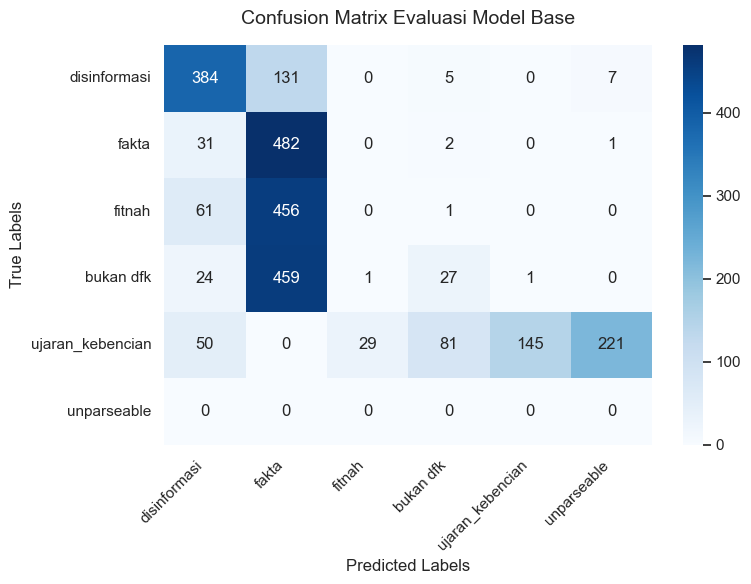

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)

# Standardize labels for comparison
y_true = df["true_label"].astype(str).str.strip().str.lower()
y_pred = df["pred_label"].astype(str).str.strip().str.lower()

# Mendapatkan urutan label unik asli dari data
labels = sorted(set(y_true) | set(y_pred))

# Kalkulasi Metrik (tetap menggunakan label asli agar perhitungan presisi)
accuracy = accuracy_score(y_true, y_pred)
macro_precision = precision_score(y_true, y_pred, average="macro", zero_division=0)
macro_recall = recall_score(y_true, y_pred, average="macro", zero_division=0)
macro_f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)
cm = confusion_matrix(y_true, y_pred, labels=labels)

print("Accuracy:", accuracy)
print("Macro Precision:", macro_precision)
print("Macro Recall:", macro_recall)
print("Macro F1:", macro_f1)
print("Confusion matrix labels:", labels)

# === MAPPING LABEL KHUSUS UNTUK TAMPILAN GAMBAR ===
# Mengubah 'non_dfk' menjadi 'bukan dfk' khusus untuk display tick gambar
display_labels = [
    "bukan dfk" if label == "non_dfk" else label for label in labels
]

# === MAPPING LABEL KHUSUS UNTUK TAMPILAN GAMBAR ===
display_labels = [
    "bukan dfk"
    if label == "non_dfk"
    else "unparseable"
    if label == "unknown"
    else label
    for label in labels
]

# === BAGIAN VISUALISASI CONFUSION MATRIX ===
plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=display_labels,  # Menggunakan label baru yang sudah di-map
    yticklabels=display_labels,  # Menggunakan label baru yang sudah di-map
    cbar=True,
)

plt.title("Confusion Matrix Evaluasi Model Base", fontsize=14, pad=15)
plt.xlabel("Predicted Labels", fontsize=12)
plt.ylabel("True Labels", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()

plt.show()

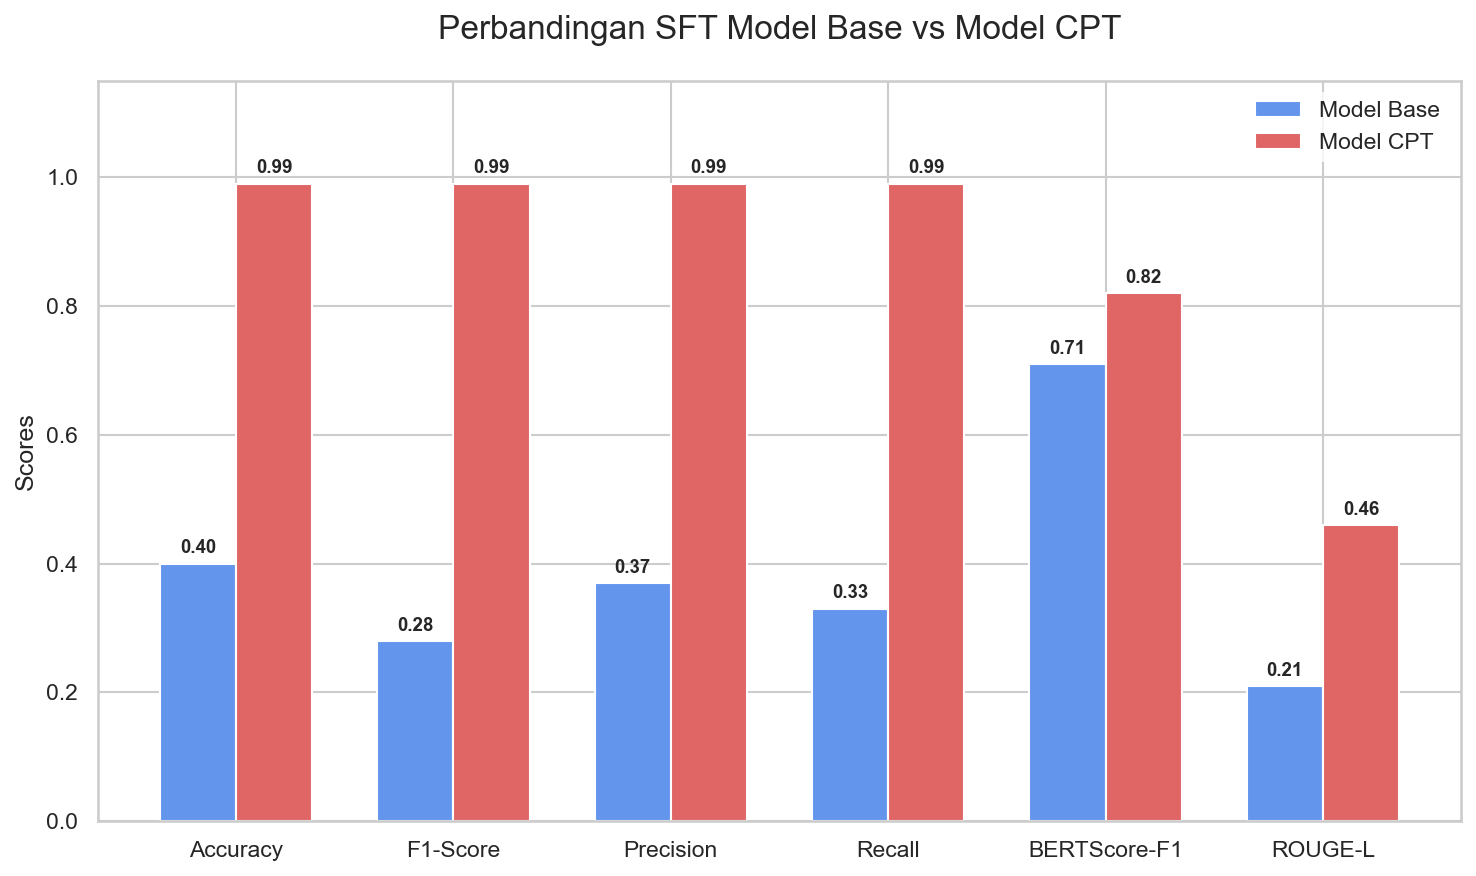

In [41]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Set style agar visualisasi terlihat modern dan bersih
sns.set_theme(style="whitegrid")

# 1. Definisikan Data
metrics = [
    "Accuracy",
    "F1-Score",
    "Precision",
    "Recall",
    "BERTScore-F1",
    "ROUGE-L",
]
model_base_scores = [0.40, 0.28, 0.37, 0.33, 0.71, 0.21]
model_cpt_scores = [0.99, 0.99, 0.99, 0.99, 0.82, 0.46]

x = np.arange(len(metrics))  # Lokasi label pada sumbu X
width = 0.35  # Lebar setiap batang

# 2. Inisiasi Plot
fig, ax = plt.subplots(figsize=(10, 6), dpi=150)

# Warna palet yang kontras dan profesional (Soft Blue & Muted Crimson/Pink)
rects1 = ax.bar(
    x - width / 2,
    model_base_scores,
    width,
    label="Model Base",
    color="#6495ED",
)
rects2 = ax.bar(
    x + width / 2, model_cpt_scores, width, label="Model CPT", color="#E06666"
)

# 3. Kustomisasi Atribut Grafik
ax.set_title("Perbandingan SFT Model Base vs Model CPT", fontsize=16, pad=20)
ax.set_ylabel("Scores", fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylim(0, 1.15)  # Beri ruang di atas untuk text label nilai

# Posisikan legend di kanan atas
ax.legend(frameon=True, facecolor="white", edgecolor="none", fontsize=11)


# 4. Fungsi untuk Menambahkan Label Angka di Atas Batang
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(
            f"{height:.2f}",
            xy=(rect.get_x() + rect.get_width() / 2, height),
            xytext=(0, 3),  # 3 points vertical offset
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=9,
            fontweight="bold",
        )


# Terapkan label nilai pada kedua model
autolabel(rects1)
autolabel(rects2)

# Sesuaikan tata letak agar tidak ada teks terpotong
plt.tight_layout()

# 5. Tampilkan Grafik
plt.show()